# Calibration analysis (probability calibration)

This notebook evaluates probability calibration for:

- bookmaker implied probability baseline (`ps_imp_p1`)
- logistic regression with odds
- logistic regression without odds

Outputs:

- calibration curves (reliability diagrams)
- Brier score
- PNG figures saved into `figures/`


In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score

os.makedirs('figures', exist_ok=True)


In [2]:
ods = pd.read_parquet('ods.parquet')
tml = pd.read_parquet('tml.parquet')
players = pd.read_parquet('players.parquet')

ods['Date'] = pd.to_datetime(ods['Date'])
tml['tourney_date'] = pd.to_datetime(tml['tourney_date'].astype(str), format='%Y%m%d', errors='coerce')

(ods.shape, tml.shape, players.shape)


((22851, 42), (24939, 50), (7643, 12))

In [3]:
def key_from_odds(name: str) -> str:
    if pd.isna(name):
        return ''
    s = str(name).strip().lower()
    s = s.replace("'", '').replace('-', ' ')
    s = re.sub(r"\s+", ' ', s)
    parts = s.split(' ')
    if not parts:
        return ''
    init = re.sub(r"[^a-z]", '', parts[-1].replace('.', ''))[:1]
    surname = re.sub(r"[^a-z\s]", '', ' '.join(parts[:-1])).strip()
    return f"{surname} {init}".strip()


def key_from_tml(full_name: str) -> str:
    if pd.isna(full_name):
        return ''
    s = str(full_name).strip().lower()
    s = s.replace("'", '').replace('-', ' ')
    s = re.sub(r"\s+", ' ', s)
    parts = s.split(' ')
    if not parts:
        return ''
    if len(parts) == 1:
        return re.sub(r"[^a-z]", '', parts[0])
    init = re.sub(r"[^a-z]", '', parts[0])[:1]
    surname = re.sub(r"[^a-z\s]", '', ' '.join(parts[1:])).strip()
    return f"{surname} {init}".strip()


In [4]:
ods['week'] = (ods['Date'] - pd.to_timedelta(ods['Date'].dt.weekday, unit='D')).dt.normalize()
tml['week'] = tml['tourney_date'].dt.normalize()

ods['wkey'] = ods['Winner'].map(key_from_odds)
ods['lkey'] = ods['Loser'].map(key_from_odds)
tml['wkey'] = tml['winner_name'].map(key_from_tml)
tml['lkey'] = tml['loser_name'].map(key_from_tml)

ods['p1'] = ods[['wkey', 'lkey']].min(axis=1)
ods['p2'] = ods[['wkey', 'lkey']].max(axis=1)
tml['p1'] = tml[['wkey', 'lkey']].min(axis=1)
tml['p2'] = tml[['wkey', 'lkey']].max(axis=1)

joined = tml.merge(
    ods,
    how='inner',
    on=['week', 'p1', 'p2'],
    suffixes=('_tml', '_ods')
)

joined.shape


(17633, 99)

In [5]:
# Build symmetric match frame: target is whether p1 won
joined = joined.copy()

joined['winner_key'] = joined['winner_name'].map(key_from_tml)
joined['loser_key'] = joined['loser_name'].map(key_from_tml)
joined['y_p1_win'] = (joined['winner_key'] == joined['p1']).astype(int)

# ranks for p1/p2
joined['rank_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['winner_rank'], joined['loser_rank'])
joined['rank_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['winner_rank'], joined['loser_rank'])
joined['rank_diff_p1_minus_p2'] = joined['rank_p1'] - joined['rank_p2']

joined['rank_points_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['winner_rank_points'], joined['loser_rank_points'])
joined['rank_points_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['winner_rank_points'], joined['loser_rank_points'])
joined['rank_points_diff_p1_minus_p2'] = joined['rank_points_p1'] - joined['rank_points_p2']

# odds for p1/p2 (B365 and Pinnacle PS)
joined['b365_odds_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['B365W'], joined['B365L'])
joined['b365_odds_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['B365W'], joined['B365L'])
joined['ps_odds_p1'] = np.where(joined['winner_key'] == joined['p1'], joined['PSW'], joined['PSL'])
joined['ps_odds_p2'] = np.where(joined['winner_key'] == joined['p2'], joined['PSW'], joined['PSL'])

# implied probabilities (normalize overround per match)
for prefix in ['b365', 'ps']:
    op1 = joined[f'{prefix}_odds_p1']
    op2 = joined[f'{prefix}_odds_p2']
    p1 = 1.0 / op1
    p2 = 1.0 / op2
    s = p1 + p2
    joined[f'{prefix}_imp_p1'] = (p1 / s).where(np.isfinite(s), np.nan)
    joined[f'{prefix}_imp_p2'] = (p2 / s).where(np.isfinite(s), np.nan)

joined['match_date'] = joined['tourney_date']

joined[['match_date','p1','p2','y_p1_win','ps_imp_p1','b365_imp_p1','rank_diff_p1_minus_p2','surface']].head(3)


,match_date,p1,p2,y_p1_win,ps_imp_p1,b365_imp_p1,rank_diff_p1_minus_p2,surface
0,2017-01-02,nishioka y,troicki v,0,0.370192,0.375000,71.0,Hard
1,2017-01-02,edmund k,escobedo e,1,0.685144,0.688073,-96.0,Hard
2,2017-01-02,pouille l,simon g,1,0.502577,0.513514,-10.0,Hard


In [6]:
def build_preprocess(num_cols, cat_cols):
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler(with_mean=False)),
    ])
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])
    return ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_cols),
            ('cat', categorical_transformer, cat_cols),
        ],
        remainder='drop'
    )


def fit_predict_models(df: pd.DataFrame, cutoff: str):
    cutoff_ts = pd.Timestamp(cutoff)
    df0 = df.dropna(subset=['y_p1_win', 'week']).copy()

    train_df = df0[df0['week'] < cutoff_ts].copy()
    test_df = df0[df0['week'] >= cutoff_ts].copy()

    y_train = train_df['y_p1_win'].astype(int)
    y_test = test_df['y_p1_win'].astype(int)

    # Define feature sets
    cols_odds = ['ps_imp_p1', 'b365_imp_p1', 'surface']
    cols_no_odds = ['rank_diff_p1_minus_p2', 'rank_points_diff_p1_minus_p2', 'surface']

    # Ensure columns exist
    cols_odds = [c for c in cols_odds if c in train_df.columns]
    cols_no_odds = [c for c in cols_no_odds if c in train_df.columns]

    # Baseline (bookmaker)
    p_ps = test_df['ps_imp_p1'].to_numpy(dtype=float)

    # Logistic regression with odds
    num_cols = [c for c in cols_odds if c != 'surface']
    cat_cols = ['surface'] if 'surface' in cols_odds else []
    pre = build_preprocess(num_cols, cat_cols)
    model_odds = Pipeline(steps=[
        ('preprocess', pre),
        ('model', LogisticRegression(max_iter=10000, solver='saga', penalty='l2', n_jobs=-1)),
    ])

    X_train = train_df[cols_odds].copy()
    X_test = test_df[cols_odds].copy()
    for oc in ['ps_imp_p1', 'b365_imp_p1']:
        if oc in X_train.columns:
            X_train[oc] = X_train[oc].fillna(0.5)
            X_test[oc] = X_test[oc].fillna(0.5)

    model_odds.fit(X_train, y_train)
    p_odds = model_odds.predict_proba(X_test)[:, 1]

    # Logistic regression without odds
    num_cols2 = [c for c in cols_no_odds if c != 'surface']
    cat_cols2 = ['surface'] if 'surface' in cols_no_odds else []
    pre2 = build_preprocess(num_cols2, cat_cols2)
    model_no = Pipeline(steps=[
        ('preprocess', pre2),
        ('model', LogisticRegression(max_iter=10000, solver='saga', penalty='l2', n_jobs=-1)),
    ])
    model_no.fit(train_df[cols_no_odds], y_train)
    p_no = model_no.predict_proba(test_df[cols_no_odds])[:, 1]

    # Optional: calibrated version of no-odds model
    calib_no = CalibratedClassifierCV(model_no, method='isotonic', cv=3)
    calib_no.fit(train_df[cols_no_odds], y_train)
    p_no_iso = calib_no.predict_proba(test_df[cols_no_odds])[:, 1]

    return {
        'y_test': y_test.to_numpy(),
        'p_ps': p_ps,
        'p_logreg_odds': p_odds,
        'p_logreg_no_odds': p_no,
        'p_logreg_no_odds_isotonic': p_no_iso,
    }


In [7]:
def plot_calibration(y_true, preds: dict, title: str, out_path: str, n_bins: int = 20):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect')

    for name, p in preds.items():
        mask = np.isfinite(p) & np.isfinite(y_true)
        yt = y_true[mask].astype(int)
        pp = np.clip(p[mask].astype(float), 1e-6, 1 - 1e-6)

        frac_pos, mean_pred = calibration_curve(yt, pp, n_bins=n_bins, strategy='uniform')
        ax.plot(mean_pred, frac_pos, marker='o', linewidth=1, label=name)

    ax.set_title(f'{title}: calibration curve')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.legend()

    ax2 = axes[1]
    for name, p in preds.items():
        mask = np.isfinite(p)
        pp = np.clip(p[mask].astype(float), 0, 1)
        ax2.hist(pp, bins=30, alpha=0.35, label=name)

    ax2.set_title(f'{title}: prediction histogram')
    ax2.set_xlabel('Predicted probability')
    ax2.set_ylabel('Count')
    ax2.legend()

    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.show()


In [8]:
def metrics_table(y_true, preds: dict):
    rows = []
    for name, p in preds.items():
        mask = np.isfinite(p) & np.isfinite(y_true)
        yt = y_true[mask].astype(int)
        pp = np.clip(p[mask].astype(float), 1e-6, 1 - 1e-6)
        rows.append({
            'model': name,
            'n': int(len(yt)),
            'brier': float(brier_score_loss(yt, pp)),
            'logloss': float(log_loss(yt, pp)),
            'roc_auc': float(roc_auc_score(yt, pp)),
        })
    return pd.DataFrame(rows).sort_values('brier')


,model,n,brier,logloss,roc_auc
0,baseline_ps_only,3448,0.206429,0.598630,0.740271
1,logreg_with_odds,3535,0.207318,0.600869,0.737450
3,logreg_no_odds_isotonic,3535,0.222474,0.635239,0.690353
2,logreg_no_odds,3535,0.222688,0.636644,0.690086


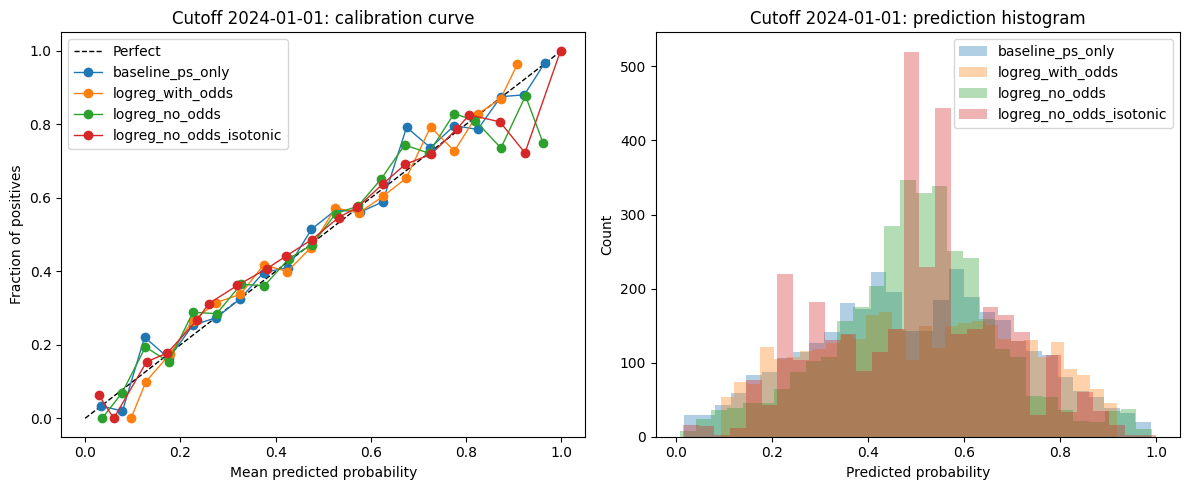

,model,n,brier,logloss,roc_auc
0,baseline_ps_only,1622,0.210391,0.608385,0.730389
1,logreg_with_odds,1702,0.210822,0.609654,0.728082
2,logreg_no_odds,1702,0.222816,0.636538,0.691528
3,logreg_no_odds_isotonic,1702,0.223146,0.636952,0.690292


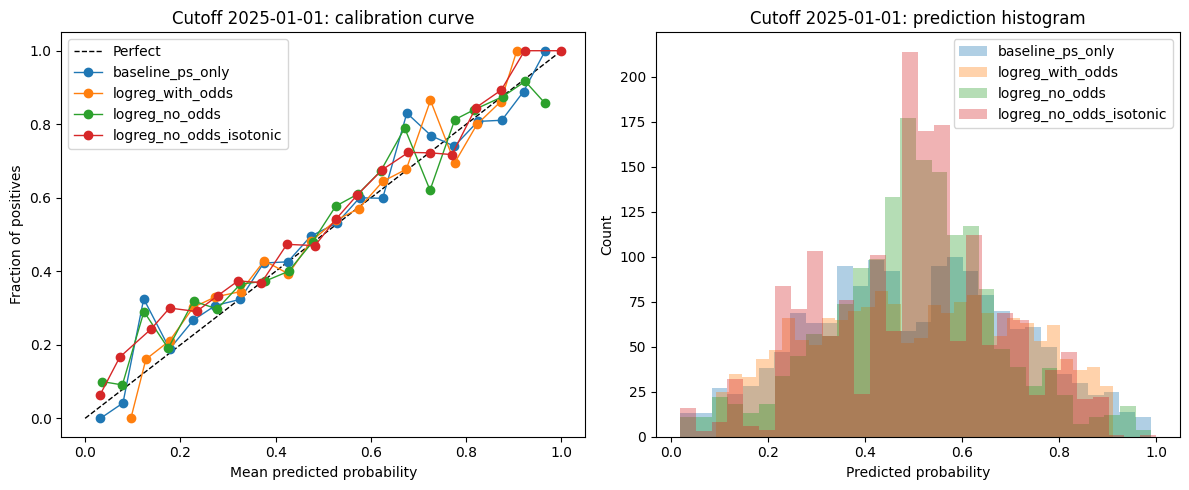

In [9]:
for cutoff in ['2024-01-01', '2025-01-01']:
    out = fit_predict_models(joined, cutoff=cutoff)
    y_test = out['y_test']

    preds = {
        'baseline_ps_only': out['p_ps'],
        'logreg_with_odds': out['p_logreg_odds'],
        'logreg_no_odds': out['p_logreg_no_odds'],
        'logreg_no_odds_isotonic': out['p_logreg_no_odds_isotonic'],
    }

    display(metrics_table(y_test, preds))
    plot_calibration(
        y_test,
        preds,
        title=f'Cutoff {cutoff}',
        out_path=f'figures/calibration_cutoff_{cutoff}.png',
        n_bins=20,
    )
